### Imports

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader, Subset
import torch.nn.functional as F

In [74]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Loading the dataset

In [75]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),   # ensure correct size
    transforms.ToTensor(),         # converts to [0,1]
])

In [76]:
train_dataset = datasets.ImageFolder(
    "/kaggle/input/datasets/saksham23456/tiny-imagenet/train",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    "/kaggle/input/datasets/saksham23456/tiny-imagenet/test",
    transform=transform
)

print(f"Classes: {train_dataset.classes}")
print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")

Classes: ['n07871810', 'n07873807', 'n07875152', 'n07920052', 'n09193705', 'n09246464', 'n09256479', 'n09332890', 'n09428293', 'n12267677']
Train size: 3500, Test size: 1000


In [77]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [78]:
LATENT_DIM = 128
IMAGE_CHANNELS = 3
IMAGE_SIZE = 64

### Defining Model VAE architecture

In [79]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.conv = nn.Sequential(
            # (B, 3, 64, 64)
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),  # → (32, 32, 32)
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # → (64, 16, 16)
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # → (128, 8, 8)
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # → (256, 4, 4)
            nn.ReLU(),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1), # → (512, 2, 2)
            nn.ReLU(),

            nn.Conv2d(512, 1024, kernel_size=4, stride=2, padding=1), # → (1024, 1, 1)
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(1024, latent_dim)
        self.fc_logvar = nn.Linear(1024, latent_dim)

    def forward(self, x):
        x = self.conv(x)                 # (B, 1024, 1, 1)
        x = x.view(x.size(0), -1)        # (B, 1024)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

In [80]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [81]:
class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()

        self.fc = nn.Linear(latent_dim, 1024)

        self.deconv = nn.Sequential(
            # reshape → (B, 1024, 1, 1)

            nn.ConvTranspose2d(1024, 512, 4, 2, 1),  # → (512, 2, 2)
            nn.ReLU(),

            nn.ConvTranspose2d(512, 256, 4, 2, 1),   # → (256, 4, 4)
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),   # → (128, 8, 8)
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),    # → (64, 16, 16)
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),     # → (32, 32, 32)
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, 4, 2, 1),      # → (3, 64, 64)
            nn.Sigmoid()  # final output in [0,1]
        )

    def forward(self, z):
        x = self.fc(z)                  # (B, 1024)
        x = x.view(-1, 1024, 1, 1)      # (B, 1024, 1, 1)
        x = self.deconv(x)
        return x

In [82]:
class VAE(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

In [83]:
model = VAE(LATENT_DIM).to(device)

### Defining the loss function and optimizer

In [84]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [85]:
def criterion(recon_x, x, mu, logvar):
    # Reconstruction loss (MSE)
    recon_loss = torch.nn.functional.mse_loss(recon_x, x, reduction='sum')

    # KL Divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss, recon_loss, kl_loss

### Model training

In [86]:
losses = []

EPOCHS = 60

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    epoch_recon_loss = 0
    epoch_kl_loss = 0

    for imgs, _ in train_loader:
        x = imgs.to(device)

        recon, mu, logvar = model(x)

        loss, recon_loss, kl_loss = criterion(recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_recon_loss += recon_loss.item()
        epoch_kl_loss += kl_loss.item()

    avg = epoch_loss / len(train_loader.dataset)
    avg_recon = epoch_recon_loss / len(train_loader.dataset)
    avg_kl = epoch_kl_loss / len(train_loader.dataset)
    losses.append(avg)

    print(f"Epoch {epoch+1}, Loss={avg:.4f}, Recon_loss={avg_recon:.4f}, KL_loss={avg_kl:.4f}")

Epoch 1, Loss=866.6778, Recon_loss=865.3938, KL_loss=1.2839
Epoch 2, Loss=789.6906, Recon_loss=782.1595, KL_loss=7.5311
Epoch 3, Loss=710.5733, Recon_loss=699.1371, KL_loss=11.4362
Epoch 4, Loss=632.3891, Recon_loss=614.9691, KL_loss=17.4200
Epoch 5, Loss=607.7387, Recon_loss=588.7710, KL_loss=18.9677
Epoch 6, Loss=587.9331, Recon_loss=567.8574, KL_loss=20.0757
Epoch 7, Loss=561.7317, Recon_loss=539.2033, KL_loss=22.5284
Epoch 8, Loss=547.1172, Recon_loss=524.6192, KL_loss=22.4980
Epoch 9, Loss=537.4177, Recon_loss=516.4486, KL_loss=20.9691
Epoch 10, Loss=528.3576, Recon_loss=507.6498, KL_loss=20.7078
Epoch 11, Loss=511.8907, Recon_loss=491.1510, KL_loss=20.7396
Epoch 12, Loss=487.7265, Recon_loss=464.1660, KL_loss=23.5605
Epoch 13, Loss=466.8730, Recon_loss=442.7033, KL_loss=24.1697
Epoch 14, Loss=454.7957, Recon_loss=430.8678, KL_loss=23.9279
Epoch 15, Loss=451.2905, Recon_loss=428.5082, KL_loss=22.7823
Epoch 16, Loss=450.3562, Recon_loss=427.9117, KL_loss=22.4445
Epoch 17, Loss=449.

### Plot of Loss vs epochs

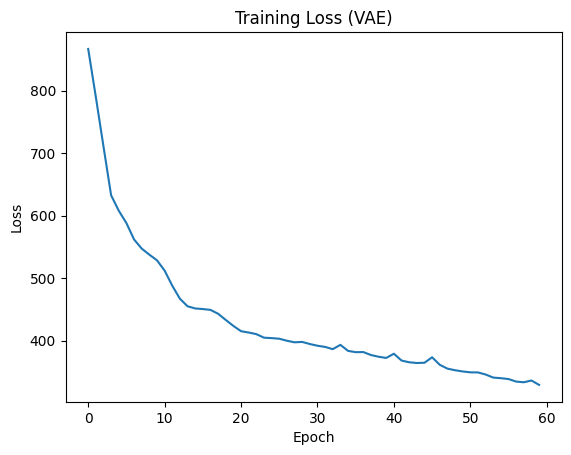

In [87]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (VAE)")
plt.show()

### Evaluating model

In [88]:
model.eval()

total_mse = 0
total_kl = 0

with torch.no_grad():
    for imgs, _ in test_loader:
        x = imgs.to(device)

        recon, mu, logvar = model(x)

        mse = torch.nn.functional.mse_loss(recon, x, reduction='sum')
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        total_mse += mse.item()
        total_kl += kl.item()

avg_mse = total_mse / len(test_loader.dataset)
avg_kl = total_kl / len(test_loader.dataset)

print(f"Test MSE: {avg_mse:.6f}")
print(f"Test KL : {avg_kl:.6f}")

Test MSE: 410.487301
Test KL : 21.249500


### Visualising the reconstructions

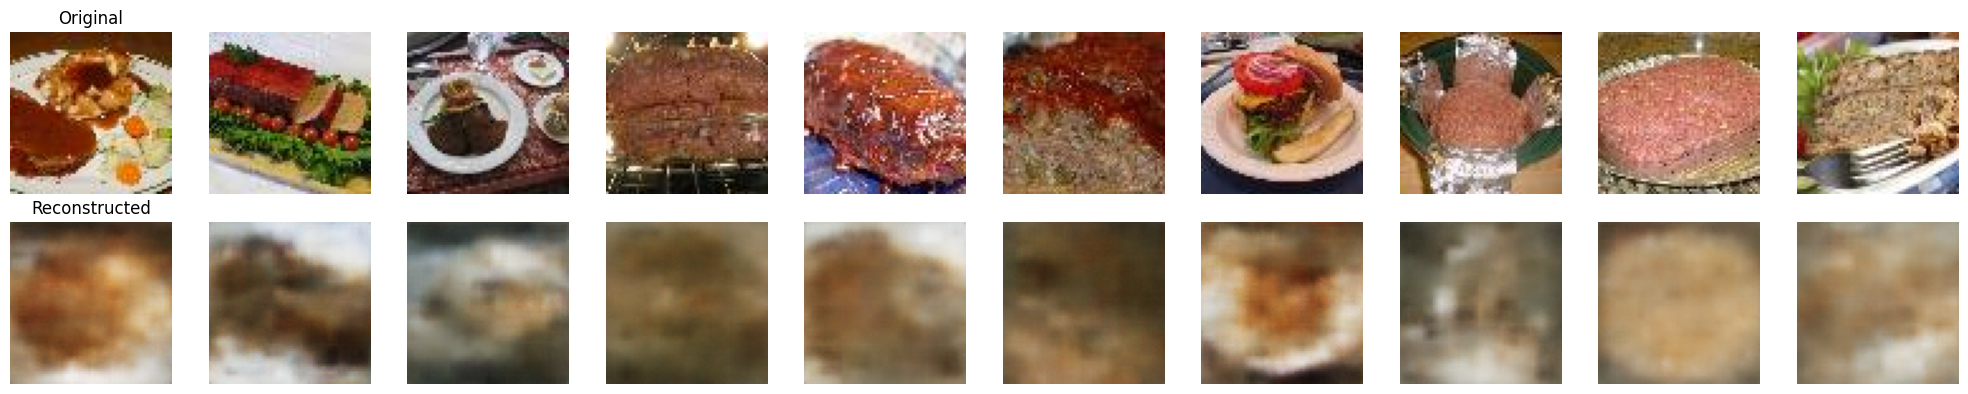

In [89]:
import matplotlib.pyplot as plt

model.eval()

imgs, _ = next(iter(test_loader))
imgs = imgs[:10].to(device)

with torch.no_grad():
    recon, _, _ = model(imgs)

imgs = imgs.cpu()
recon = recon.cpu()

fig, axes = plt.subplots(2, 10, figsize=(20, 4))

for i in range(10):
    # Original
    axes[0, i].imshow(imgs[i].permute(1, 2, 0))
    axes[0, i].axis('off')

    # Reconstruction
    axes[1, i].imshow(recon[i].permute(1, 2, 0))
    axes[1, i].axis('off')

axes[0, 0].set_title("Original", fontsize=12)
axes[1, 0].set_title("Reconstructed", fontsize=12)

plt.tight_layout()
plt.show()